### TASK 1

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Data Types and Missing Values ---
            Data Type  Missing Values  Percentage (%)
survived        int64               0            0.00
pclass          int64               0            0.00
sex            object               0            0.00
age           float64             177           19.87
sibsp           int64               0            0.00
parch           int64               0            0.00
fare          float64               0            0.00
embarked       object               2            0.22
class        category               0            0.00
who            object               0            0.00
adult_male       bool               0            0.00
deck         category             688           77.22
embark_town    object               2            0.22
alive          object               0            0.00
alone            bool               0            0.00

Survival Rate: 38.38%


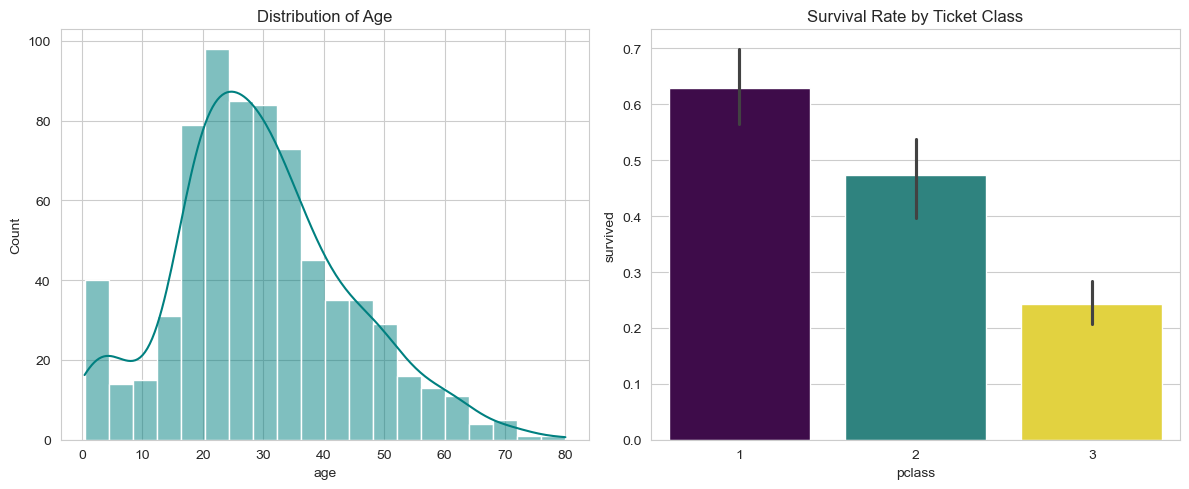

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

titanic = sns.load_dataset("titanic")


print("Dataset Shape:", titanic.shape)
display(titanic.head())

# Data types and missing values
print("\n--- Data Types and Missing Values ---")
info_df = pd.DataFrame({
    'Data Type': titanic.dtypes,
    'Missing Values': titanic.isnull().sum(),
    'Percentage (%)': (titanic.isnull().sum() / len(titanic) * 100).round(2)
})
print(info_df)

# Class Balance
survival_rate = titanic['survived'].mean() * 100
print(f"\nSurvival Rate: {survival_rate:.2f}%")

# Visualation
plt.figure(figsize=(12, 5))

#1.Numerical
plt.subplot(1, 2, 1)
sns.histplot(titanic['age'].dropna(), kde=True, color='teal')
plt.title('Distribution of Age')

# 2. Survival rate by Class (Categorical)
plt.subplot(1, 2, 2)
sns.barplot(x='pclass', y='survived', data=titanic, hue='pclass', palette='viridis', legend=False)
plt.title('Survival Rate by Ticket Class')

plt.tight_layout()
plt.show()

### Summary



## Summary of Data Exploration Findings

### Dataset Structure
The dataset contains **891 rows and 15 columns**. It includes both:
- **Numerical features** (e.g., `age`, `fare`)
- **Categorical features** (e.g., `sex`, `embarked`, `pclass`)

---

### Data Quality & Missing Values
- The `deck` column has approximately **77% missing values**, making it largely unusable for modeling.
- The `age` column has about **19.8% missing values**, which should be handled through imputation.
- The `embarked` column has only **2 missing values**, which can be easily filled.

---

### Class Balance
The overall survival rate is approximately **38.4%**.  
This indicates that the target variable (`survived`) is **somewhat imbalanced**, with **more passengers not surviving than surviving**.

---

### Key Observations

#### Age Distribution
Most passengers fall within the **20–40 age range**.

#### Class Impact
Visual analysis shows that passengers in **1st class (`pclass = 1`)** had a **significantly higher survival rate** compared to other classes.  
This suggests that **ticket class is a strong predictor of survival**.

### TASK 2

In [2]:
# 1. Missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic.drop(columns=['deck'], inplace=True)

# 2. Encoding
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex']) # male: 1, female: 0

# One-hot encoding for embarked
titanic = pd.get_dummies(titanic, columns=['embarked'], drop_first=True)

# 3. New Features
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

# 4. Drop non-numeric/redundant columns
cols_to_drop = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'alone']
titanic_cleaned = titanic.drop(columns=cols_to_drop)

print("Final DataFrame Columns:")
print(titanic_cleaned.dtypes)
display(titanic_cleaned.head())

non_numeric = titanic_cleaned.select_dtypes(exclude=[np.number, 'bool']).columns
if len(non_numeric) == 0:
    print("\n All Columns are numeric.")
else:
    print(f"\nAll Clomn are't numeric {list(non_numeric)}")

Final DataFrame Columns:
survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q        bool
embarked_S        bool
family_size      int64
is_alone         int64
dtype: object


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,True,1,1
3,1,1,0,35.0,1,0,53.1000,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,True,1,1



 All Columns are numeric.


### TASK 3

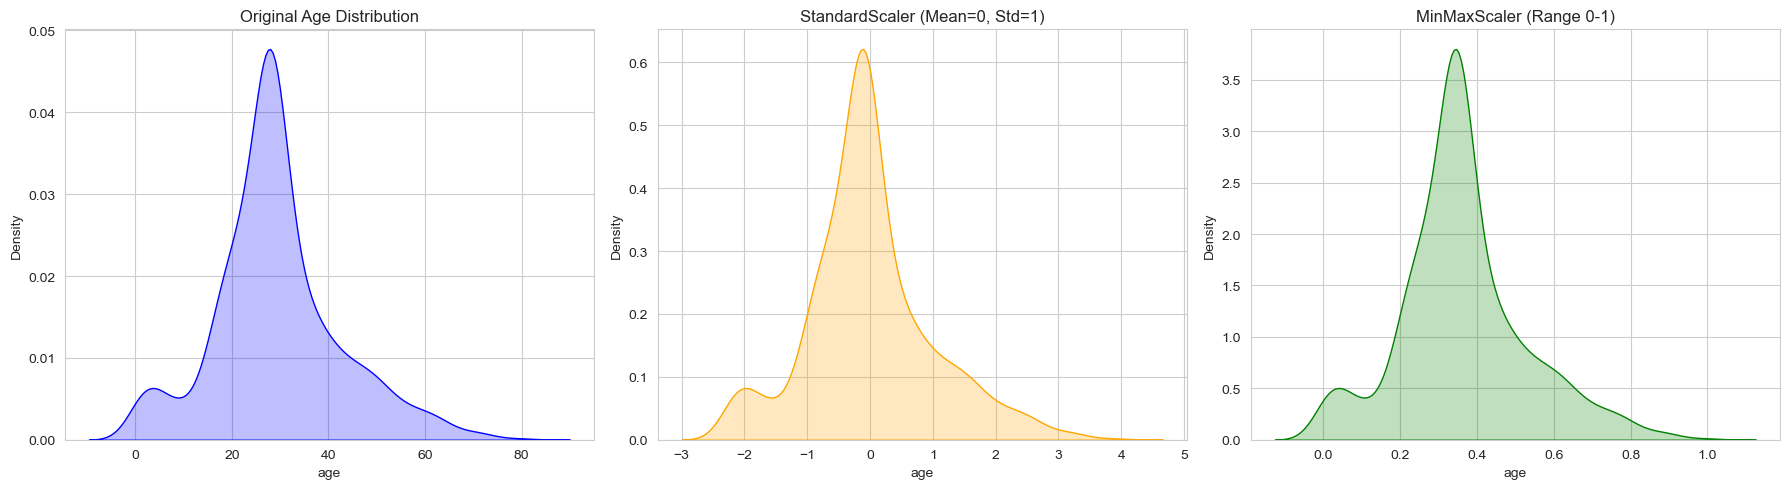

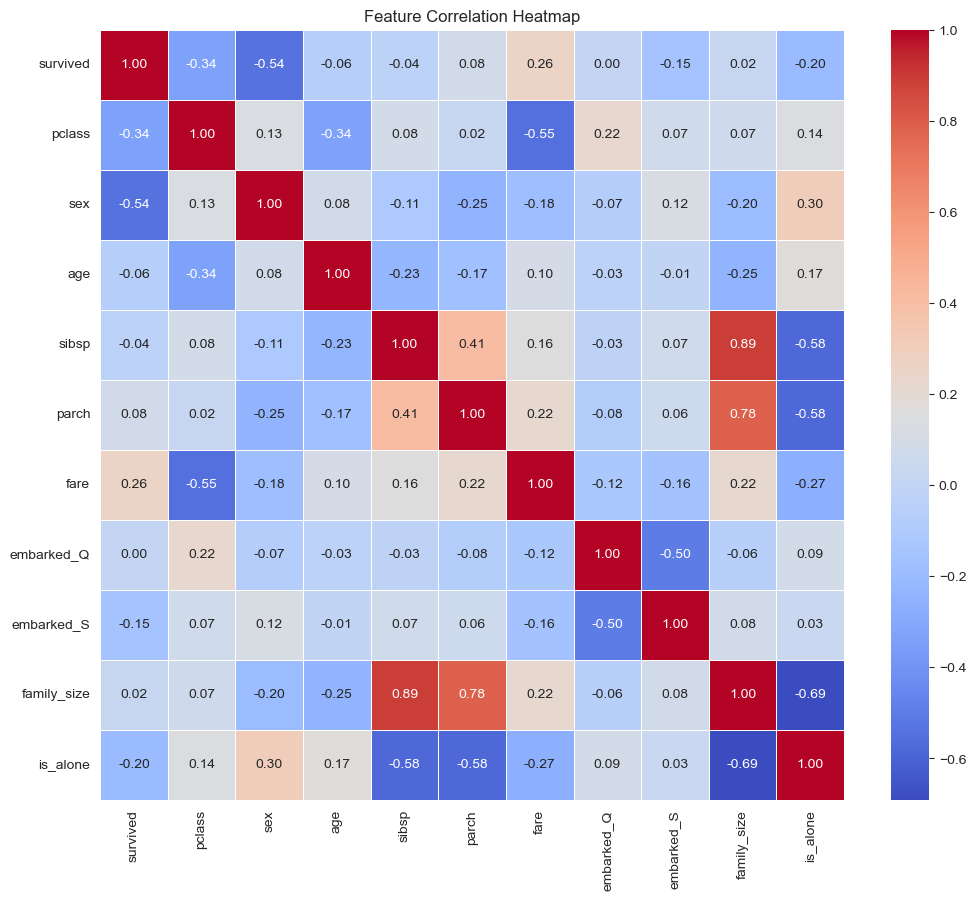

Top features with absolute correlation >= 0.1:
survived      1.000000
sex           0.543351
pclass        0.338481
fare          0.257307
is_alone      0.203367
embarked_S    0.149683
Name: survived, dtype: float64


In [3]:
# --- Feature Scaling Comparison ---
# Prepare features for scaling (Age and Fare have different ranges)
features_to_scale = ['age', 'fare']
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

# Create copies to compare results
df_std = titanic_cleaned.copy()
df_minmax = titanic_cleaned.copy()

# Apply transformations
df_std[features_to_scale] = scaler_std.fit_transform(titanic_cleaned[features_to_scale])
df_minmax[features_to_scale] = scaler_minmax.fit_transform(titanic_cleaned[features_to_scale])

# Visualization: Distribution of Age before and after scaling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original Data
sns.kdeplot(titanic_cleaned['age'], ax=axes[0], fill=True, color='blue')
axes[0].set_title('Original Age Distribution')

# StandardScaler Result
sns.kdeplot(df_std['age'], ax=axes[1], fill=True, color='orange')
axes[1].set_title('StandardScaler (Mean=0, Std=1)')

# MinMaxScaler Result
sns.kdeplot(df_minmax['age'], ax=axes[2], fill=True, color='green')
axes[2].set_title('MinMaxScaler (Range 0-1)')

plt.tight_layout()
plt.show()

# --- Correlation Analysis ---
plt.figure(figsize=(12, 10))
correlation_matrix = titanic_cleaned.corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# --- Feature Selection ---
# Identify features with absolute correlation >= 0.1 with the target 'survived'
target_correlation = correlation_matrix['survived'].abs().sort_values(ascending=False)
top_features = target_correlation[target_correlation >= 0.1]

print("Top features with absolute correlation >= 0.1:")
print(top_features)

## Difference Between Scalers

### StandardScaler
StandardScaler transforms the data so that:
- The **mean becomes 0**
- The **standard deviation becomes 1**

This method standardizes features by removing the mean and scaling to unit variance.  
It is generally **more robust to outliers** compared to MinMaxScaler, although extreme values can still influence the scaling.

---

### MinMaxScaler
MinMaxScaler rescales all feature values into a fixed range, typically:
- **[0, 1]**

It preserves the **original distribution shape** of the data.  
However, it is **sensitive to outliers**, meaning that extreme values can compress the majority of the data into a very small range.

### -----------------------------------------------------------------

## Correlation & Feature Selection

### Strongest Predictors
The features **`sex`**, **`pclass`**, and **`fare`** show the strongest correlation with the target variable (`survived`).  
This aligns with historical context:
- The **“women and children first”** policy increased survival rates for females.
- Passengers in **higher classes** had better access to lifeboats and resources.

---

### Engineered Features
The engineered feature **`is_alone`** shows a notable negative correlation (**-0.20**).  
This suggests that passengers traveling **with family or companions** had a higher chance of survival compared to those traveling alone.

---

### Dropped / Borderline Features
- Features like **`family_size`** or specific **`embarked`** categories show **weaker linear correlations** with survival.
- Some features (e.g., **`age`**) are logically important but exhibit **weak linear correlation** because their relationship with survival is **non-linear**:
  - Very young passengers → higher survival  
  - Very old passengers → lower survival  
  - Middle-aged passengers → mixed outcomes  

This mixed pattern reduces the overall linear correlation, even though the feature still carries meaningful information.

---

### Conclusion
Feature selection was based not only on correlation strength but also on **domain knowledge** and **understanding of non-linear relationships**, ensuring that important variables are not discarded prematurely.

### TASK 4

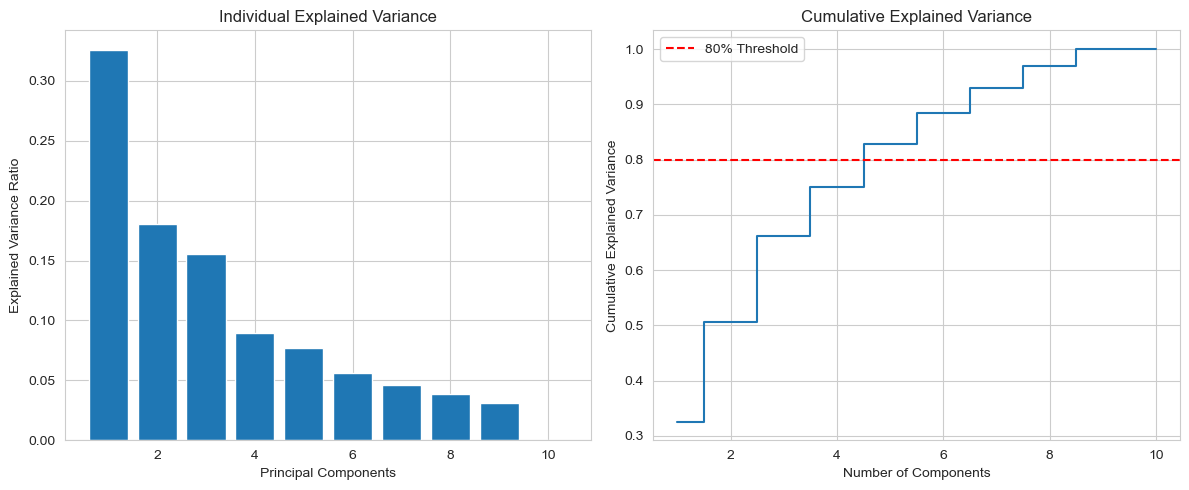

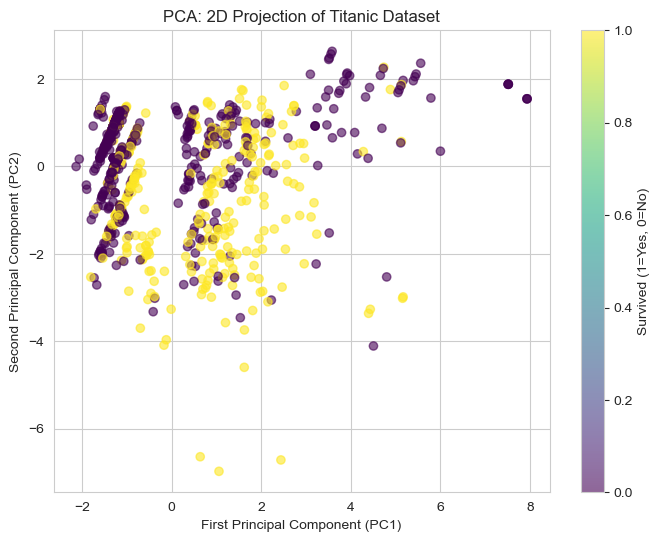

In [4]:
# 1. Standardization (Mandatory for PCA)
# Separate features (X) and target (y)
X = titanic_cleaned.drop(columns=['survived'])
y = titanic_cleaned['survived']

# PCA is sensitive to the scale of features, so we use StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# 2. Fit PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_scaled)

# --- Variance Plotting ---
plt.figure(figsize=(12, 5))

# Bar chart for individual explained variance
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance')

# Line chart for cumulative explained variance
plt.subplot(1, 2, 2)
plt.step(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         np.cumsum(pca_full.explained_variance_ratio_), where='mid')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Refit PCA with 2 components for 2D Visualization
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Survived (1=Yes, 0=No)')
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title('PCA: 2D Projection of Titanic Dataset')
plt.show()

## PCA Analysis & Dimensionality Reduction

### 1. Variance Analysis
Based on the cumulative explained variance plot, approximately **5 to 6 principal components** are required to capture at least **80% of the total variance** in the dataset.  
Using only **2 components** captures significantly less variance, indicating that a substantial amount of information is lost in a 2D projection.

---

### 2. Class Separation
In the scatter plot of the first two principal components:
- There is **some overlap** between survivors and non-survivors.
- A **slight separation trend** is visible:
  - One cluster (likely representing **females and first-class passengers**) is shifted along the **PC1 axis**.
  
However, this separation is **not strong enough** to clearly distinguish the classes using only two dimensions.

---

### 3. Is PCA Necessary for This Dataset?

#### Does it help?
- PCA is useful for:
  - **Visualizing high-dimensional data**
  - **Reducing noise**
- However, in this case, it does **not significantly improve classification performance**.

---

### Recommendation
For the Titanic dataset:
- The original feature space is **already small (~10 features)**.
- Key features like **`sex`** and **`pclass`** are:
  - Highly **interpretable**
  - Strong **predictors of survival**

As a result, dimensionality reduction using PCA provides **limited benefit**.

PCA is more useful for datasets with **hundreds or thousands of features**, where the **curse of dimensionality** becomes a major issue.